## Analyis of Algorithm

In [1]:
library(terra)
library(sf)
library(dplyr)
library(lwgeom)
library(tidyverse)
library(tictoc)
library(tmap)

terra 1.8.93
Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE

Attaching package: ‘dplyr’

The following objects are masked from ‘package:terra’:

    intersect, union

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Linking to liblwgeom 3.0.0beta1 r16016, GEOS 3.12.1, PROJ 9.4.0

Attaching package: ‘lwgeom’

The following objects are masked from ‘package:sf’:

    st_minimum_bounding_circle, st_perimeter

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.2     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────

In [2]:
terraOptions(memfrac = 0.9)

In [3]:
getwd()

[1] "/home/etienne/Desktop/repos/Github_Enterprise/BSc_project/code"

### 1. Load in the data

In [4]:

r <- terra::rast("../data/thermal_rasters_FINAL/mean_v01emme.tif")

line <- sf::st_read("../data/Centerlines_FINAL/Emme_V01.shp", quiet = TRUE) |> sf::st_zm(TRUE, "ZM")


In [5]:
stopifnot(terra::nlyr(r) == 1) # if not only one layer
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")


In [6]:
rres   <- terra::res(r)
cell_m <- mean(rres)



In [7]:
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))

}

# This specific object has only one line, somehtimes there are multible ->  then
# we need to do a join.
line

Simple feature collection with 1 feature and 2 fields
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
  NAME   Length                       geometry
1 Emme 30165.01 LINESTRING (2620465 1205048...

In [8]:
g <- sf::st_union(line)

Dont realy know why this is. It seems to me like this is necessairy because not all data is the same -> Better leave it in

---
### Parameters of the Function

In [9]:
step_m            = 500       # slab length along centerline (m)
buffer_px         = 3         # corridor half-width for reference T (pixels)
delta_C           = 1.0       # temperature anomaly threshold (deg C)
min_patch_area_m2 = 2         # drop patches smaller than this
round_to          = 0.1       # round temperatures to this precision
slab_halfwidth_m  = 60        # lateral half-width of slab polygons (m)
connect_diagonals = TRUE      # 8-connectivity when dissolving patches
union_chunk_size  = 50000L    # max cells per dissolve chunk
epsilon = 0.01

In [10]:
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }

In [11]:
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)


In [12]:
rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

rfactor

[1] 10

In [13]:
toc()


**Timing**

This first set of steps is very fast. That was to be exected. terra only holds a pointer to the data in memory. Only upon evaluation, data is actually read. sf I am not quite shure. But it is also reasonable, that loading a single line into memory is not computationally expensive. So all the checks of coordinate reference systems etc.

---
### 2. Building slabs

In [14]:
L <- as.numeric(sf::st_length(line))
S <- step_m

# I am quite shure this has its good reasons why it is how it is.
# if seq yields NULL or something, then you still got a vector with a 0
pos <- sort(unique(c(0, seq(0,1, by = S/ L), 1)))

# number of positions ?
npt <- length(pos)

# this returns a warning, if we e.g. want to do step size 5000m but
# the river segment is not even 5000 m long
if (npt < 2) stop("Too few stations for step = ", S)

# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]


# this returns a list filled with NULL
subs_list <- vector("list", k)


# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)



In [15]:
# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]

g1

Geometry set for 1 feature 
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
LINESTRING (2620465 1205048, 2620390 1205056, 2...

In [16]:
# this returns a list filled with NULL
subs_list <- vector("list", k)

subs_list %>% head()

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL


In [17]:
# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)



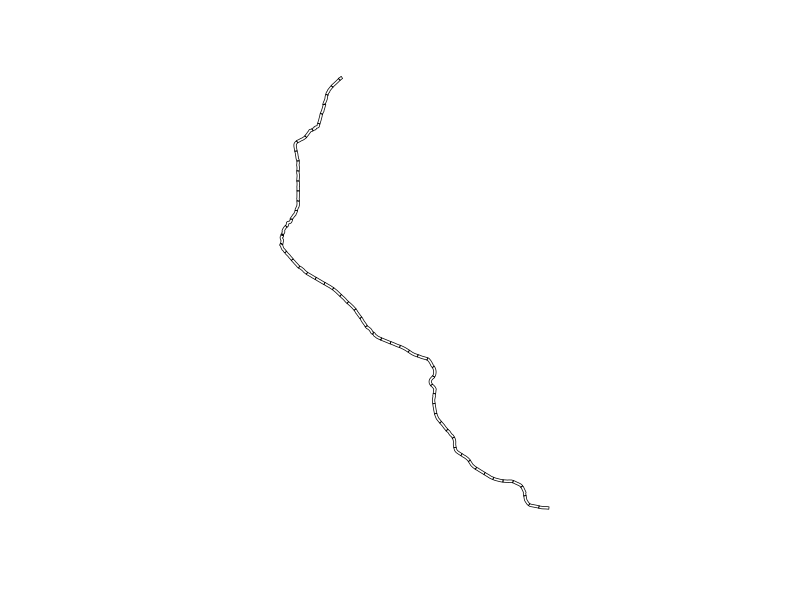

In [18]:
slabs_sf %>% plot()

These are nsome nice slaps ngl

In [19]:
toc()

In [20]:
?st_buffer

**Timing**

This slap building steps also seems to be rather fast. No wonder, as the geodata in play here is very light weight and the rest are just native R functions. (So far this is great but Im rather certain, that the whole number crunching is up ahead)

---
### 3. Extract slab pixels

In [21]:
slabs_terra <- terra::vect(slabs_sf)

In [22]:
# terra::extract(r, slabs_terra, cells = TRUE)

This seems to be very very memory intensive. (It is, since this basically creates a dataframe that holds a row for every pixel.) Idk, this is maybe a super fast way of doing this whole reference temperature calculations if one has enough memory (I don't). But on the HPC i have plenty of memory.

I guess I will still try to find an alternative way of doing this here. Ofc, the computations over the resulting dataframe can be parallelized (because some of these reference temperature calculations are embarissingly parallel + every slab on its own is parallel too). But I can also parallelize this in terra (hopefully). I think I could build the buffer means using

rasterisation of thinner slaps -> zonal operation with the thiner slap raster. And then I could do reclassification of the big slaps using the means of the smaller slaps (median buffers) as burn in. Then all that would be left is some raster algebra.

The neat part is, that this is all powered by GDAL (like almost everything ofc.). So on the hpc i can just try to krank up the number of threads used by gdal and potentially allready get a decent speedup without even changing that much about the code.

In [23]:
buffer_m <- cell_m *  buffer_px

slabs_buffer <- sf::st_buffer(subs,
                          dist        = buffer_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_buffer_sf <- sf::st_sf(geometry = slabs_buffer)


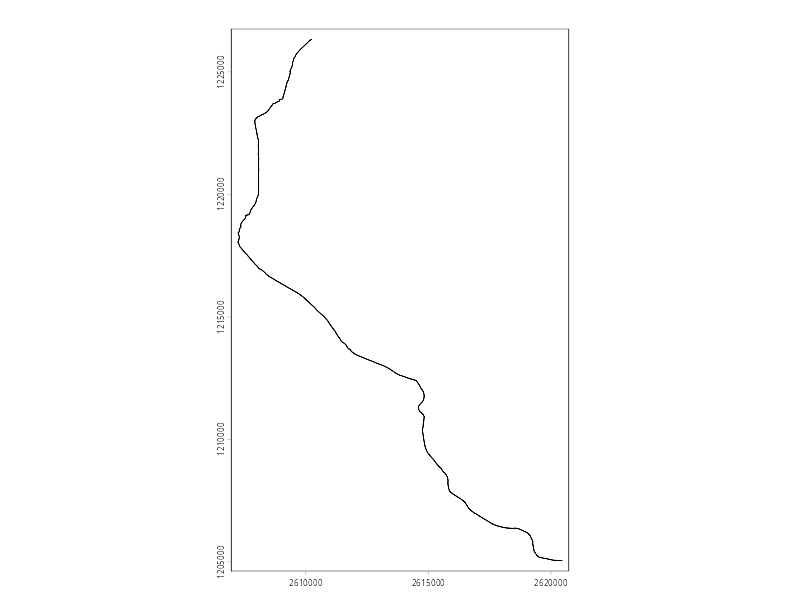

In [24]:
slaps_buffer_vect <- slabs_buffer_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()


slaps_buffer_vect %>% plot()

In [25]:
zone_r <- terra::rasterize(slaps_buffer_vect, r, field = "slap_id")

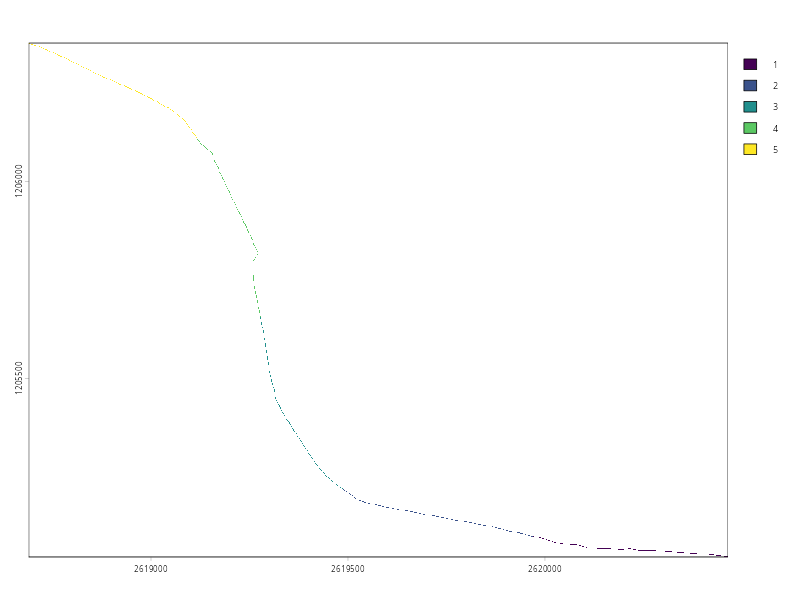

In [26]:
# The full raster is ~64k x ~103k pixels at 0.207m resolution.
# At that scale, 6-pixel-wide buffer slabs appear as sub-pixel dots.
# Zoom into the first few slabs to verify they are real polygons:
ext_zoom <- terra::ext(slaps_buffer_vect[1:5, ])
terra::plot(terra::crop(zone_r, ext_zoom))
#terra::plot(slaps_buffer_vect[1:5, ], add = TRUE, border = "red")

In [27]:
mean_raster <- terra::zonal(r, zone_r,fun = "mean", na.rm = TRUE)

In [28]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_raster <- terra::rast()

In [ ]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_sf <- sf::st_sf(geometry = slabs)


slaps_sf_vect <- slabs_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()




In [1]:
tic()
zone_r_big <- terra::rasterize(slaps_sf_vect, r, field = "slap_id")
toc()

: [1m[33mError[39m:[22m
[33m![39m could not find function "tic"

In [ ]:
tic()
sf::write_sf(slabs_sf,"../data/test_dir/slabs_sf.shp")

system(
"gdal vector rasterize -i ../data/test_dir/slabs_sf.shp -o ../data/test_dir/zone_r_big.tif -a slap_id --resolution 0.20728,0.20728 --overwrite --extent 2607201,1212140,2620465,1226340"
)

zone_r_big <- terra::rast("../data/test_dir/zone_r_big.tif")
toc()

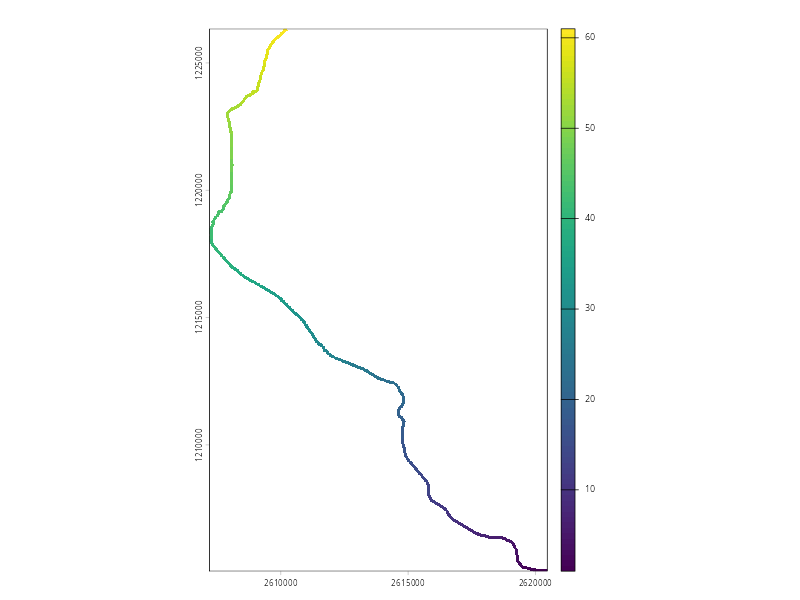

In [30]:
plot(zone_r_big)

In [31]:
Tmean <- terra::classify(zone_r_big,mean_raster)

In [ ]:

flagged_pixels <- r_r - Tmean



In [76]:
alg <- function(a,b) {a  - b}

In [ ]:
r_stack <- c(r, Tmean)

terra::lapp(r_stack, fun = alg, cores = 4)

In [33]:

binary <- flagged_pixels <= (-1* delta_C)



In [34]:

binary[binary==0] <- NA

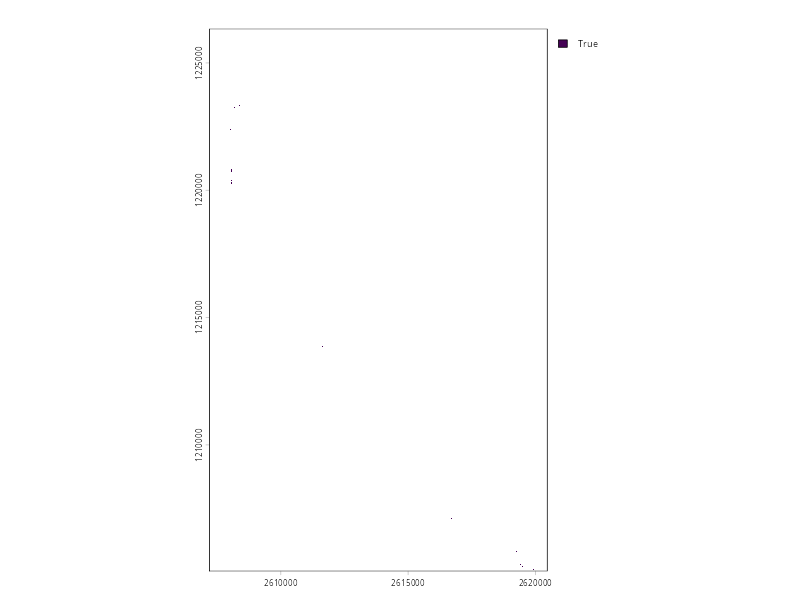

In [35]:
binary %>% plot()

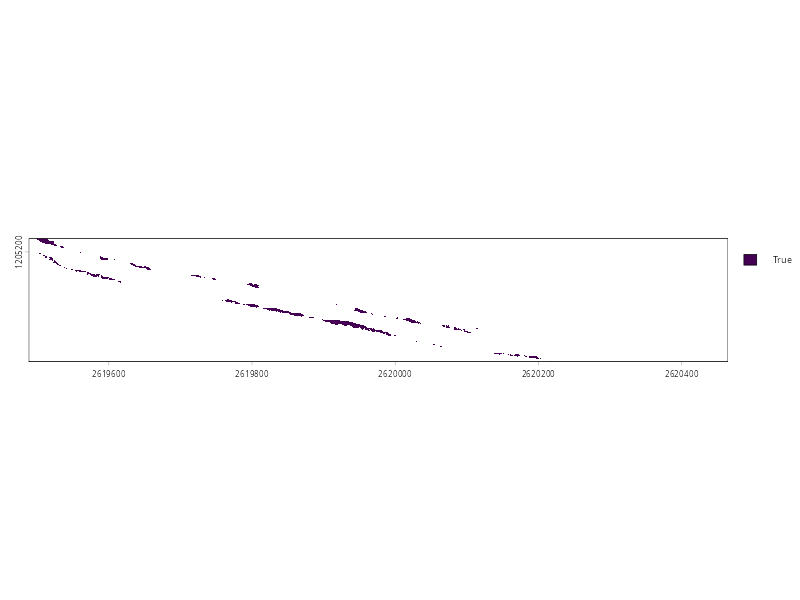

In [36]:
ext_zoom <- terra::ext(slaps_buffer_vect[1:2, ])
terra::plot(terra::crop(binary, ext_zoom))

In [37]:


patches_v <- terra::as.polygons(binary,
                                dissolve = TRUE,
                                eight    = FALSE)

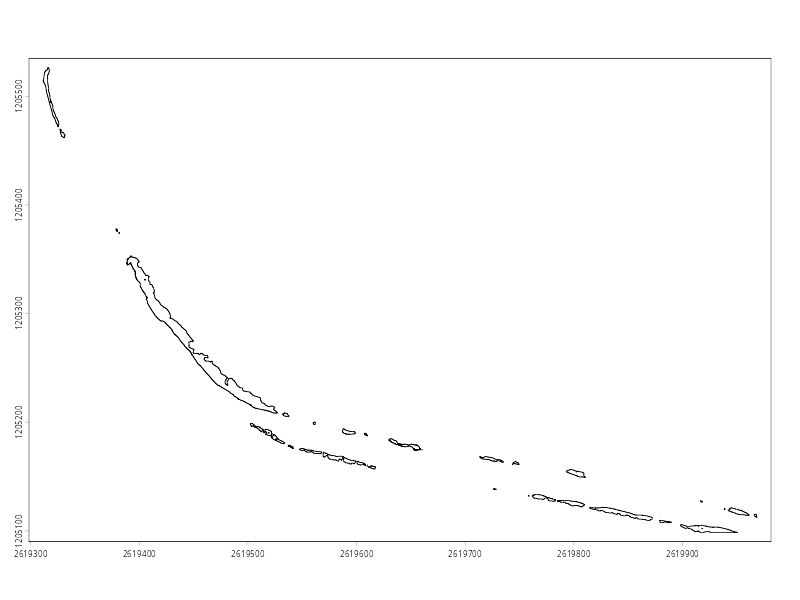

In [38]:
ext_zoom <- terra::ext(slaps_buffer_vect[2:3, ])
terra::plot(terra::crop(patches_v, ext_zoom))

In [64]:
eps <- if (connect_diagonals) cell_m  * 0.1 else 0

patches_sf <- patches_v %>%
  sf::st_as_sf() %>%
  sf::st_cast("POLYGON") %>% 
  sf::st_buffer(eps) %>%
  sf::st_union() %>%
  sf::st_buffer(-eps) %>%
  sf::st_cast("POLYGON") %>%
  sf::st_as_sf()

Warning message:
In st_cast.sf(., "POLYGON") :
  repeating attributes for all sub-geometries for which they may not be constant


In [73]:
patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2) %>%
  mutate(ID = row_number())

In [71]:
patches_large <- patches_sf %>%
  mutate(
    area = as.numeric(st_area(.))
  ) %>%
  filter(area >= 2) %>%
  mutate(ID = row_number())

A connectivity of eight is no longer needed since this logic is allready a side effect of the morphological closing.

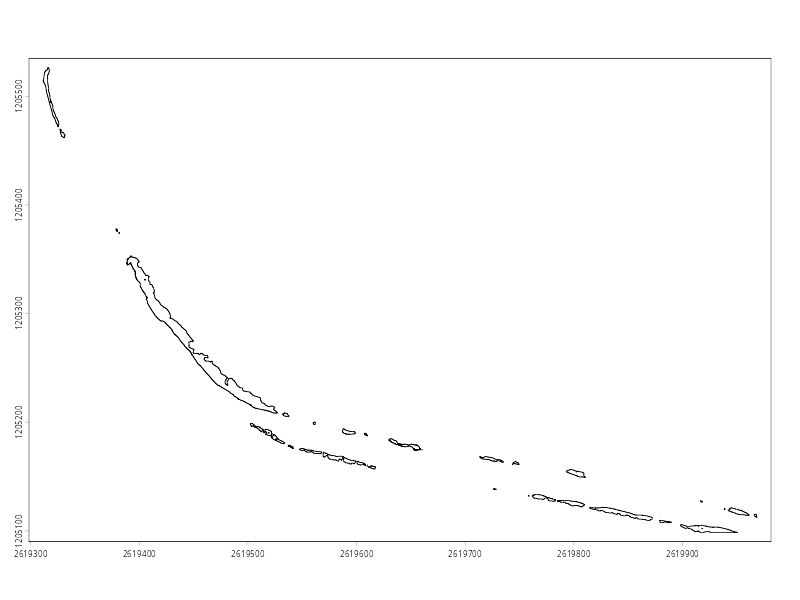

In [40]:
ext_zoom <- terra::ext(slaps_buffer_vect[2:3, ])
terra::plot(terra::crop(patches_v, ext_zoom))

In [41]:
patches_sf <- sf::st_as_sf(patches_v) %>% sf::st_cast("POLYGON") 



Warning message:
In st_cast.sf(., "POLYGON") :
  repeating attributes for all sub-geometries for which they may not be constant


In [42]:
patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2) %>%
  mutate(ID = row_number())


patches_large

Simple feature collection with 117 features and 2 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2607201 ymin: 1205050 xmax: 2620203 ymax: 1225804
Projected CRS: CH1903+ / LV95
First 10 features:
      T                       geometry ID
1.2   1 POLYGON ((2609691 1225804, ...  1
1.6   1 POLYGON ((2609653 1225790, ...  2
1.8   1 POLYGON ((2609676 1225787, ...  3
1.10  1 POLYGON ((2609669 1225776, ...  4
1.11  1 POLYGON ((2609663 1225767, ...  5
1.12  1 POLYGON ((2609619 1225702, ...  6
1.13  1 POLYGON ((2609591 1225657, ...  7
1.188 1 POLYGON ((2609177 1224328, ...  8
1.216 1 POLYGON ((2608440 1223407, ...  9
1.258 1 POLYGON ((2608230 1223267, ... 10

In [43]:
stats_per_poly <- terra::extract(r,patches_large) %>%
  group_by(ID) %>%
  summarise(
    mean_temp = mean(T),
    min_temp = min(T),
    max_temp = max(T),
    median_temp = median(T)
  )

stats_per_poly

# A tibble: 117 × 5
      ID mean_temp min_temp max_temp median_temp
   <dbl>     <dbl>    <dbl>    <dbl>       <dbl>
 1     1      19.5     17.4     19.9        19.8
 2     2      18.8     18.0     19.8        18.7
 3     3      19.8     19.7     19.9        19.9
 4     4      19.7     18.9     19.9        19.8
 5     5      17.8     16.7     19.9        17.5
 6     6      18.6     16.7     19.9        18.8
 7     7      18.1     16.5     19.9        18.2
 8     8      19.5     19.5     19.6        19.6
 9     9      19.4     19.1     19.6        19.4
10    10      18.1     17.4     19.6        17.7
# ℹ 107 more rows
# ℹ Use `print(n = ...)` to see more rows

In [44]:
stats_per_poly

# A tibble: 117 × 5
      ID mean_temp min_temp max_temp median_temp
   <dbl>     <dbl>    <dbl>    <dbl>       <dbl>
 1     1      19.5     17.4     19.9        19.8
 2     2      18.8     18.0     19.8        18.7
 3     3      19.8     19.7     19.9        19.9
 4     4      19.7     18.9     19.9        19.8
 5     5      17.8     16.7     19.9        17.5
 6     6      18.6     16.7     19.9        18.8
 7     7      18.1     16.5     19.9        18.2
 8     8      19.5     19.5     19.6        19.6
 9     9      19.4     19.1     19.6        19.4
10    10      18.1     17.4     19.6        17.7
# ℹ 107 more rows
# ℹ Use `print(n = ...)` to see more rows

In [45]:
patches_large_with_stas <- patches_large  %>%
  left_join(stats_per_poly, by = "ID") %>%
    select(!T)

In [46]:
patches_large_with_stas %>% colnames()

[1] "ID"          "mean_temp"   "min_temp"    "max_temp"    "median_temp" "geometry"   

In [47]:
slab_means <-terra::extract(Tmean, vect(patches_large_with_stas), fun ="mean" ) %>%
  rename(slab_mean_T = slap_id)

In [48]:
patches_large_with_stas <- patches_large  %>%
  left_join(stats_per_poly, by = "ID") %>%
    select(!T)

final_patches <- patches_large_with_stas %>%
  left_join(slab_means, by = "ID") %>%
  mutate(deltaT = slab_mean_T - mean_temp) %>%
  filter(deltaT >= delta_C)


final_patches

Simple feature collection with 117 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2607201 ymin: 1205050 xmax: 2620203 ymax: 1225804
Projected CRS: CH1903+ / LV95
First 10 features:
   ID mean_temp min_temp max_temp median_temp slab_mean_T                       geometry   deltaT
1   1  19.51852 17.41273 19.93048    19.79858    20.93082 POLYGON ((2609691 1225804, ... 1.412298
2   2  18.76966 18.04250 19.80846    18.67249    20.93082 POLYGON ((2609653 1225790, ... 2.161165
3   3  19.83766 19.65713 19.93000    19.86273    20.93082 POLYGON ((2609676 1225787, ... 1.093163
4   4  19.66133 18.88653 19.92964    19.84624    20.93082 POLYGON ((2609669 1225776, ... 1.269493
5   5  17.81316 16.71403 19.89684    17.51840    20.93082 POLYGON ((2609663 1225767, ... 3.117660
6   6  18.56007 16.72549 19.91997    18.77168    20.93082 POLYGON ((2609619 1225702, ... 2.370751
7   7  18.11144 16.45720 19.92277    18.21997    20.93082 POLYGON ((2609591 1225657, ... 2.81937

ℹ tmap modes "plot" - "view"
ℹ toggle with ]8;;x-r-run:tmap::ttm()tmap::ttm()]8;;
This message is displayed once per session.


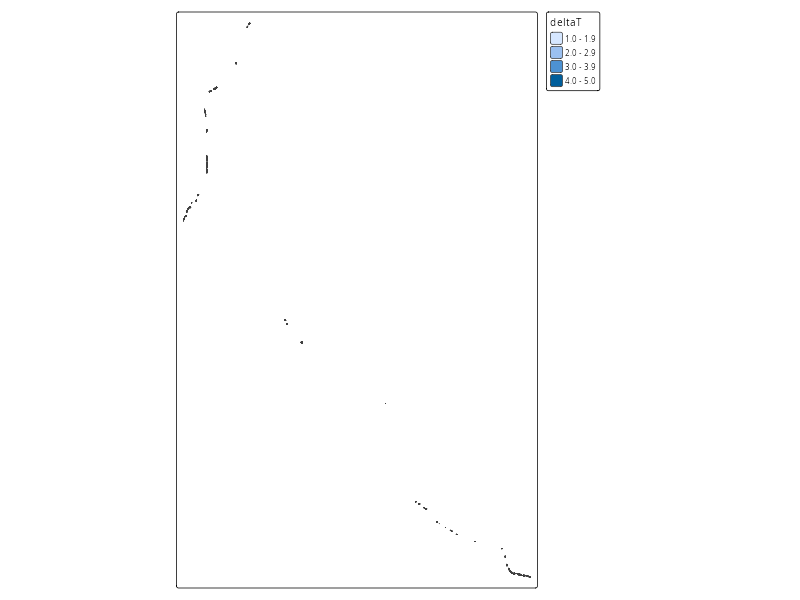

In [49]:
tmap_mode("plot")

tm_shape(final_patches) +
    tm_polygons(fill = "deltaT")

In [50]:
detect_cwp_single <- function(
    ras_path,
    line_path,
    step_m            = 500,
    buffer_px         = 3,
    delta_C           = 1.0,
    min_patch_area_m2 = 2,
    round_to          = 0.1,
    slab_halfwidth_m  = 60,
    connect_diagonals = TRUE,
    union_chunk_size  = 50000L
) {

r <- terra::rast(ras_path)
line <- sf::st_read(line_path, quiet = TRUE) |> sf::st_zm(TRUE, "ZM")
  
stopifnot(terra::nlyr(r) == 1)
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")

rres   <- terra::res(r)
cell_m <- mean(rres)

if (!is.na(sf::st_crs(line)) &&
  !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
  line <- sf::st_transform(line, terra::crs(r))
}

g <- sf::st_union(line)
  
if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
  g <- sf::st_collection_extract(g, "LINESTRING")
if (inherits(g, "sfc_MULTILINESTRING")) {
  g <- sf::st_line_merge(g)
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
}
  
rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

L <- as.numeric(sf::st_length(line))
S <- step_m

pos <- sort(unique(c(0, seq(0, 1, by = S / L), 1)))
npt <- length(pos)

if (npt < 2) stop("Too few stations for step = ", S)

from <- pos[1:(npt - 1)]
to   <- pos[2:npt]
k    <- length(from)

g1 <- sf::st_geometry(line)[1]

subs_list <- vector("list", k)
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

subs <- do.call(c, subs_list)

slabs <- sf::st_buffer(subs,
                       dist        = slab_halfwidth_m,
                       endCapStyle = "FLAT",
                       joinStyle   = "MITRE",
                       mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)

slabs_terra <- terra::vect(slabs_sf)

buffer_m <- cell_m * buffer_px

slabs_buffer <- sf::st_buffer(subs,
                              dist        = buffer_m,
                              endCapStyle = "FLAT",
                              joinStyle   = "MITRE",
                              mitreLimit  = 2)
slabs_buffer_sf <- sf::st_sf(geometry = slabs_buffer)

slaps_buffer_vect <- slabs_buffer_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()

slabs <- sf::st_buffer(subs,
                       dist        = slab_halfwidth_m,
                       endCapStyle = "FLAT",
                       joinStyle   = "MITRE",
                       mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)

slaps_sf_vect <- slabs_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()

zone_r_big <- terra::rasterize(slaps_sf_vect, r, field = "slap_id")

r_rounded <- round(r * rfactor) / rfactor

zone_r <- terra::rasterize(slaps_buffer_vect, r_rounded, field = "slap_id")

mean_raster <- terra::zonal(r_rounded, zone_r, fun = "median", na.rm = TRUE)

Tmean <- terra::classify(zone_r_big, mean_raster)

flagged_pixels <- r_rounded - Tmean
binary <- flagged_pixels <= (-1 * delta_C)

binary[binary == 0] <- NA
patches_v <- terra::as.polygons(binary, dissolve = TRUE, eight = FALSE)

eps <- if (connect_diagonals) cell_m * 0.1 else 0

patches_sf <- patches_v %>%
  sf::st_as_sf() %>%
  sf::st_cast("POLYGON") %>%
  sf::st_buffer(eps) %>%
  sf::st_union() %>%
  sf::st_buffer(-eps)

patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2) %>%
  mutate(ID = row_number())

stats_per_poly <- terra::extract(r_rounded, patches_large) %>%
  group_by(ID) %>%
  summarise(
    mean_temp   = mean(T),
    min_temp    = min(T),
    max_temp    = max(T),
    median_temp = median(T)
  )

patches_large_with_stas <- patches_large %>%
  left_join(stats_per_poly, by = "ID") %>%
  select(!T)

slab_means <- terra::extract(Tmean, vect(patches_large_with_stas), fun = "mean") %>%
  rename(slab_mean_T = slap_id)

final_patches <- patches_large_with_stas %>%
  left_join(slab_means, by = "ID") %>%
  mutate(deltaT = slab_mean_T - mean_temp) %>%
  filter(deltaT >= delta_C)

return(final_patches)

}

## The original function

In [ ]:
polygonize_flagged_vector <- function(flagged_cells, r,
                                      chunk_size   = 50000L,
                                      connect_diag = TRUE) {

  if (!length(flagged_cells)) {
    return(sf::st_sf(geometry = sf::st_sfc(), crs = sf::st_crs(terra::crs(r))))
  }

  res    <- terra::res(r)
  crs_wk <- terra::crs(r)

  make_rects_sfc <- function(xc, yc, rx, ry, crs_wk) {
    polys <- vector("list", length(xc))
    for (i in seq_along(xc)) {
      x <- xc[i]; y <- yc[i]
      m <- matrix(c(
        x - rx/2, y - ry/2,
        x + rx/2, y - ry/2,
        x + rx/2, y + ry/2,
        x - rx/2, y + ry/2,
        x - rx/2, y - ry/2
      ), ncol = 2, byrow = TRUE)
      polys[[i]] <- sf::st_polygon(list(m))
    }
    sf::st_sfc(polys, crs = sf::st_crs(crs_wk))
  }

  n      <- length(flagged_cells)
  chunks <- split(seq_len(n), ceiling(seq_len(n) / chunk_size))
  parts_sv <- vector("list", length(chunks))

  for (ci in seq_along(chunks)) {
    idx <- chunks[[ci]]
    xy  <- terra::xyFromCell(r, flagged_cells[idx])
    sfc <- make_rects_sfc(xy[, 1], xy[, 2], res[1], res[2], crs_wk)

    v       <- terra::vect(sf::st_sf(geometry = sfc))
    v$grp   <- 1L
    vd      <- terra::aggregate(v, by = "grp")
    parts_sv[[ci]] <- vd
  }

  parts_sf <- lapply(parts_sv, sf::st_as_sf)
  stitched <- do.call(rbind, parts_sf)
  geom     <- sf::st_geometry(stitched)
  geom     <- try(sf::st_make_valid(geom), silent = TRUE)

  eps <- if (connect_diag) min(res) * 0.1 else 0

  if (eps > 0) {
    merged <- sf::st_union(sf::st_buffer(geom, eps))
    merged <- sf::st_buffer(merged, -eps)
  } else {
    merged <- sf::st_union(geom)
  }

  polys <- sf::st_collection_extract(merged, "POLYGON", warn = FALSE)
  polys <- suppressWarnings(sf::st_cast(polys, "POLYGON"))
  sf::st_sf(geometry = polys)
}

In [ ]:
# =============================================================================
detect_cwp_single <- function(
    ras_path,
    line_path,
    step_m            = 500,       # slab length along centerline (m)
    buffer_px         = 3,         # corridor half-width for reference T (pixels)
    delta_C           = 1.0,       # temperature anomaly threshold (deg C)
    min_patch_area_m2 = 2,         # drop patches smaller than this
    round_to          = 0.1,       # round temperatures to this precision
    slab_halfwidth_m  = 60,        # lateral half-width of slab polygons (m)
    connect_diagonals = TRUE,      # 8-connectivity when dissolving patches
    union_chunk_size  = 50000L     # max cells per dissolve chunk
) {

  timings <- numeric()
  tic <- function() proc.time()[["elapsed"]]

  # ── 0. READ INPUTS ────────────────────────────────────────────────────────
  t0 <- tic()

  r <- terra::rast(ras_path)
  stopifnot(terra::nlyr(r) == 1)
  names(r) <- "T"
  if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")
  rres   <- terra::res(r)
  cell_m <- mean(rres)

  line <- sf::st_read(line_path, quiet = TRUE) |> sf::st_zm(TRUE, "ZM")
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))
  }
  g <- sf::st_union(line)
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)

  rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

  timings[["read_inputs"]] <- tic() - t0

  # ── 1. BUILD SLABS ────────────────────────────────────────────────────────
  t0 <- tic()

  L   <- as.numeric(sf::st_length(line))
  S   <- step_m
  pos <- sort(unique(c(0, seq(0, 1, by = S / L), 1)))
  npt <- length(pos)
  if (npt < 2) stop("Too few stations for step = ", S)

  from <- pos[1:(npt - 1)]
  to   <- pos[2:npt]
  k    <- length(from)
  g1   <- sf::st_geometry(line)[1]

  subs_list <- vector("list", k)
  for (j in seq_len(k)) {
    subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
  }
  subs  <- do.call(c, subs_list)
  slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
  slabs_sf <- sf::st_sf(geometry = slabs)

  timings[["build_slabs"]] <- tic() - t0

  # ── 2. EXTRACT SLAB PIXELS ────────────────────────────────────────────────
  t0 <- tic()

  slab_df <- terra::extract(r, terra::vect(slabs_sf), cells = TRUE)
  slab_df <- slab_df[!is.na(slab_df$T), , drop = FALSE]
  if (!nrow(slab_df)) stop("No pixels found inside slabs.")
  if (!is.na(rfactor)) slab_df$T <- round(slab_df$T * rfactor) / rfactor
  by_slab <- split(slab_df[, c("ID", "cell", "T")], slab_df$ID)

  timings[["extract_slab_pixels"]] <- tic() - t0

  # ── 3. COMPUTE REFERENCE TEMPERATURES (median per slab corridor) ───────
  t0 <- tic()

  Rm <- buffer_px * cell_m

  median_round <- function(x) {
    x <- x[!is.na(x)]
    if (!length(x)) return(NA_real_)
    if (!is.na(rfactor)) x <- round(x * rfactor) / rfactor
    stats::median(x)
  }

  Tmed <- numeric(k)
  for (j in seq_len(k)) {
    corridor_j <- sf::st_buffer(
      sf::st_sfc(subs[j], crs = sf::st_crs(line)),
      dist        = Rm,
      endCapStyle = "FLAT",
      joinStyle   = "MITRE",
      mitreLimit  = 2
    )
    vals_df  <- terra::extract(r, terra::vect(sf::st_sf(geometry = corridor_j)))
    v        <- vals_df[[names(r)[1]]]
    Tmed[j]  <- median_round(v)
  }

  timings[["compute_ref_temps"]] <- tic() - t0

  # ── 4. FLAG COLD PIXELS ───────────────────────────────────────────────────
  t0 <- tic()

  flagged <- integer(0L)
  for (j in seq_along(by_slab)) {
    tm <- Tmed[j]
    if (is.na(tm)) next
    dfj  <- by_slab[[j]]
    keep <- dfj$cell[(tm - dfj$T) >= delta_C]
    if (length(keep)) flagged <- c(flagged, keep)
  }
  flagged <- unique(flagged)

  timings[["flag_pixels"]] <- tic() - t0

  # ── 5. POLYGONIZE FLAGGED CELLS ────────────────────────────────────────────
  t0 <- tic()

  if (!length(flagged)) {
    pol_sf <- sf::st_sf(geometry = sf::st_sfc(), crs = sf::st_crs(line))
  } else {
    pol_sf <- polygonize_flagged_vector(flagged, r,
                                         chunk_size   = union_chunk_size,
                                         connect_diag = connect_diagonals)
  }

  timings[["polygonize"]] <- tic() - t0

  # ── 6. AREA FILTER (drop small patches) ───────────────────────────────────
  t0 <- tic()

  if (inherits(pol_sf, "sfc"))
    pol_sf <- sf::st_sf(geometry = pol_sf, crs = sf::st_crs(line))

  if (nrow(pol_sf) > 0) {
    pol_sf$area_m2 <- tryCatch(
      as.numeric(sf::st_area(pol_sf)),
      error = function(e)
        as.numeric(terra::expanse(terra::vect(pol_sf), unit = "m", transform = FALSE))
    )
    pol_sf <- dplyr::filter(pol_sf, area_m2 >= min_patch_area_m2)
  }

  timings[["area_filter"]] <- tic() - t0

  # ── 7. TEMPERATURE STATISTICS PER PATCH ────────────────────────────────────
  t0 <- tic()

  if (nrow(pol_sf) > 0) {
    pol_v     <- terra::vect(pol_sf)
    vals_list <- terra::extract(r, pol_v)
    vals_list <- split(vals_list[[names(r)[1]]], vals_list$ID)

    get_stats <- function(x) {
      x <- x[!is.na(x)]
      if (!length(x)) return(rep(NA_real_, 4))
      c(min(x), max(x), stats::median(x), mean(x))
    }
    stats_mat           <- t(vapply(vals_list, get_stats, numeric(4)))
    colnames(stats_mat) <- c("T_min", "T_max", "T_med", "T_mean")
    pol_sf$T_min  <- stats_mat[, "T_min"]
    pol_sf$T_max  <- stats_mat[, "T_max"]
    pol_sf$T_med  <- stats_mat[, "T_med"]
    pol_sf$T_mean <- stats_mat[, "T_mean"]

    # Assign slab reference temperature to each patch
    cell_extract <- terra::extract(r, pol_v, cells = TRUE)
    cell_extract <- cell_extract[!is.na(cell_extract$cell), ]

    cell_to_slab_list <- lapply(seq_along(by_slab), function(j) {
      df <- by_slab[[j]]
      if (nrow(df) == 0) return(NULL)
      data.frame(cell = df$cell, slab_id = j)
    })
    cell_to_slab <- do.call(rbind, cell_to_slab_list)

    merged_df <- merge(cell_extract, cell_to_slab, by = "cell", all.x = TRUE)

    slab_meds <- tapply(merged_df$slab_id, merged_df$ID, function(ids) {
      if (all(is.na(ids))) return(NA_real_)
      stats::median(Tmed[ids], na.rm = TRUE)
    })
    pol_sf$Tmed_slab <- as.numeric(slab_meds[as.character(seq_len(nrow(pol_sf)))])

    pol_sf$deltaT       <- pol_sf$Tmed_slab - pol_sf$T_med
    pol_sf$delta_thresh <- delta_C

    # Second filter: patch-level delta must meet threshold
    pol_sf <- dplyr::filter(pol_sf, deltaT >= delta_C)
  }

  timings[["patch_stats"]] <- tic() - t0

  # ── TOTAL ──────────────────────────────────────────────────────────────────
  timings[["TOTAL"]] <- sum(timings)

  list(patches = pol_sf, timings = timings)
}
